<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>investment strategy based on sentiment index(Jun Wang)</B></font></td></tr></table>

this is a replication of the paper: [Quantifying Trading Behavior in Financial Markets Using Google Trends](https://www.nature.com/articles/srep01684), you can get the code from [financial-analysis-python-tutorial](https://github.com/twiecki/financial-analysis-python-tutorial)

In [1]:
import pandas as pd
from datetime import datetime,date
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
pd.options.mode.chained_assignment = None
%matplotlib inline

# Financial analysis using google trends

## 搜索行为与买卖行为相关

# moving average	

In [2]:
data = pd.read_csv('GoogleTrendsData.csv', index_col='Date', parse_dates=True)

In [3]:
data.head()

,djia,debt
Date,,
2004-01-14,10485.18,0.210000
2004-01-22,10528.66,0.210000
2004-01-28,10702.51,0.210000
2004-02-04,10499.18,0.213333
2004-02-11,10579.03,0.200000


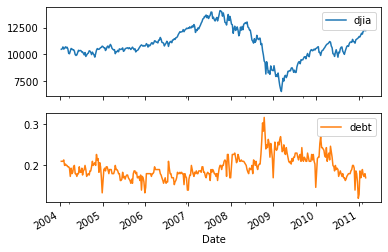

In [4]:
data.plot(subplots=True) 

# 先进行数据探索，利用相反趋势，构建策略 
# 使用一个搜索关键词

plt.savefig("dd.png")

<AxesSubplot:xlabel='Date'>

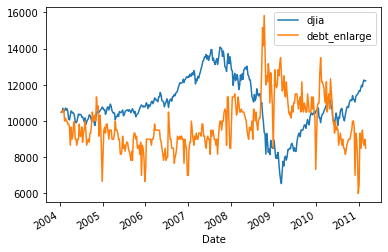

In [5]:
data["debt_enlarge"] = data["debt"] * 50000 

# 量纲统一，放在一个图里

data.loc[:,["djia","debt_enlarge"]].plot()

The authors detect if search volume is relatively increasing or decreasing in any given week by forming a moving average and testing if the current value crosses the moving average of the past 3 weeks.

Lets first compute the moving average.

In [6]:
data['debt_mavg'] = data.debt.rolling(window=3).mean() 

# 比较某一周相对前几周的变化，计算前面几周的移动平均值

In [7]:
data.head(8)

,djia,debt,debt_enlarge,debt_mavg
Date,,,,
2004-01-14,10485.18,0.210000,10500.00,NaN
2004-01-22,10528.66,0.210000,10500.00,NaN
2004-01-28,10702.51,0.210000,10500.00,0.210000
2004-02-04,10499.18,0.213333,10666.65,0.211111
2004-02-11,10579.03,0.200000,10000.00,0.207778
2004-02-19,10714.88,0.203333,10166.65,0.205555
2004-02-25,10609.62,0.200000,10000.00,0.201111
2004-03-03,10678.14,0.200000,10000.00,0.201111


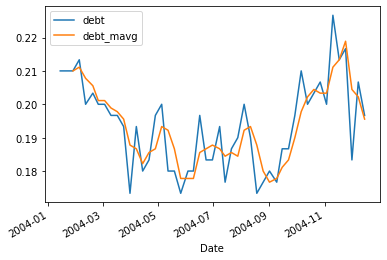

In [8]:
data.loc[:'2004-12-17',['debt','debt_mavg']].plot()
plt.savefig("moving.png")

<AxesSubplot:xlabel='Date'>

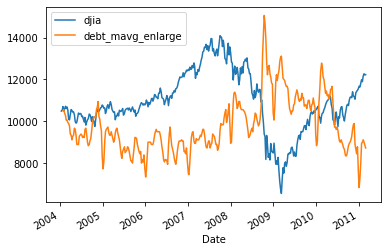

In [9]:
data["debt_mavg_enlarge"] = data["debt_mavg"] * 50000  

### 量纲处理

data.loc[:,["djia","debt_mavg_enlarge"]].plot()

In [10]:
data.head()

,djia,debt,debt_enlarge,debt_mavg,debt_mavg_enlarge
Date,,,,,
2004-01-14,10485.18,0.210000,10500.00,NaN,NaN
2004-01-22,10528.66,0.210000,10500.00,NaN,NaN
2004-01-28,10702.51,0.210000,10500.00,0.210000,10500.000000
2004-02-04,10499.18,0.213333,10666.65,0.211111,10555.550000
2004-02-11,10579.03,0.200000,10000.00,0.207778,10388.883333


To quantify changes in information gathering behavior, we use the relative change in search volume.
Since we want to see if the current value is above the moving average of the *preceeding* weeks, 
we have to shift the moving average timeseries forward by one.

In [11]:
data['debt_mavg'] = data.debt_mavg.shift(1) 

# 当周 跟 前三周的进行比较，需要用shift下移一个位置

data.head()

,djia,debt,debt_enlarge,debt_mavg,debt_mavg_enlarge
Date,,,,,
2004-01-14,10485.18,0.210000,10500.00,NaN,NaN
2004-01-22,10528.66,0.210000,10500.00,NaN,NaN
2004-01-28,10702.51,0.210000,10500.00,NaN,10500.000000
2004-02-04,10499.18,0.213333,10666.65,0.210000,10555.550000
2004-02-11,10579.03,0.200000,10000.00,0.211111,10388.883333


Generate the order signals.
===========================

From the paper:

"We use Google Trends to determine how many searches n(t – 1) have been carried out for a specific search term such as debt in week t – 1, where Google defines weeks as ending on a Sunday, relative to the total number of searches carried out on Google during that time."

"We implement this strategy by selling the DJIA at the closing price p(t) on the first trading day of week t, if Δn(t − 1, Δt) > 0, and buying the DJIA at price p(t + 1) at the end of the first trading day of the following week. [...]. If instead Δn(t − 1, Δt) < 0, then we buy the DJIA at the closing price p(t) on the first trading day of week t and sell the DJIA at price p(t + 1) at the end of the first trading day of the coming week."

交易信号-交易决策

做空：Δn(t − 1, Δt) > 0 在**第t周**的第一个交易日收盘价**去卖**，在**第t+1周**的第一个交易日收盘价**去买**回来

做多：Δn(t − 1, Δt) < 0 在**第t周**的第一个交易日收盘价**去买**，在**第t+1周**的第一个交易日收盘价**去卖**出去

In [12]:
data['order'] = 0 ## hold的意思

data["order"][data.debt > data.debt_mavg] = -1 # Short if search volume goes up relative to mavg. 做空
data['order'][data.debt < data.debt_mavg] = 1 # Long if search volume goes down relative to mavg. 做多

data["order"] = data.order.shift(1)

### 下一周的策略，下一周执行操作

In [13]:
data.head(10)

,djia,debt,debt_enlarge,debt_mavg,debt_mavg_enlarge,order
Date,,,,,,
2004-01-14,10485.18,0.210000,10500.00,NaN,NaN,NaN
2004-01-22,10528.66,0.210000,10500.00,NaN,NaN,0.0
2004-01-28,10702.51,0.210000,10500.00,NaN,10500.000000,0.0
2004-02-04,10499.18,0.213333,10666.65,0.210000,10555.550000,0.0
2004-02-11,10579.03,0.200000,10000.00,0.211111,10388.883333,-1.0
2004-02-19,10714.88,0.203333,10166.65,0.207778,10277.766667,1.0
2004-02-25,10609.62,0.200000,10000.00,0.205555,10055.550000,1.0
2004-03-03,10678.14,0.200000,10000.00,0.201111,10055.550000,1.0
2004-03-10,10529.48,0.196667,9833.35,0.201111,9944.450000,1.0


# Compute returns

In [14]:
data['ret_djia'] = data.djia.pct_change() 

###道琼斯指数变化百分比

print(data[["djia","ret_djia","order"]].head(15))

                djia  ret_djia  order
Date                                 
2004-01-14  10485.18       NaN    NaN
2004-01-22  10528.66  0.004147    0.0
2004-01-28  10702.51  0.016512    0.0
2004-02-04  10499.18 -0.018998    0.0
2004-02-11  10579.03  0.007605   -1.0
2004-02-19  10714.88  0.012841    1.0
2004-02-25  10609.62 -0.009824    1.0
2004-03-03  10678.14  0.006458    1.0
2004-03-10  10529.48 -0.013922    1.0
2004-03-17  10102.89 -0.040514    1.0
2004-03-24  10064.75 -0.003775    1.0
2004-03-31  10329.63  0.026318    1.0
2004-04-07  10558.37  0.022144    1.0
2004-04-14  10515.56 -0.004055   -1.0
2004-04-21  10437.85 -0.007390    1.0


Returns at week t are relative to week t-1. However, we are buying at week t and selling at week t+1, so we have to adjust by shifting the returns upward.

In [15]:
data['ret_djia_shift'] = data['ret_djia'].shift(-1) 

## 收益率的变动，要向上回调一下

In [16]:
data.head(10)   ### 要使用 order 乘以 向上变动的收益（收益率的变动）

,djia,debt,debt_enlarge,debt_mavg,debt_mavg_enlarge,order,ret_djia,ret_djia_shift
Date,,,,,,,,
2004-01-14,10485.18,0.210000,10500.00,NaN,NaN,NaN,NaN,0.004147
2004-01-22,10528.66,0.210000,10500.00,NaN,NaN,0.0,0.004147,0.016512
2004-01-28,10702.51,0.210000,10500.00,NaN,10500.000000,0.0,0.016512,-0.018998
2004-02-04,10499.18,0.213333,10666.65,0.210000,10555.550000,0.0,-0.018998,0.007605
2004-02-11,10579.03,0.200000,10000.00,0.211111,10388.883333,-1.0,0.007605,0.012841
2004-02-19,10714.88,0.203333,10166.65,0.207778,10277.766667,1.0,0.012841,-0.009824
2004-02-25,10609.62,0.200000,10000.00,0.205555,10055.550000,1.0,-0.009824,0.006458
2004-03-03,10678.14,0.200000,10000.00,0.201111,10055.550000,1.0,0.006458,-0.013922
2004-03-10,10529.48,0.196667,9833.35,0.201111,9944.450000,1.0,-0.013922,-0.040514


The algorithm that is used by the authors makes a decision every Monday of whether to long or short the Dow Jones. After this week passed, we exit all positions (sell if we longed, buy if we shorted) and make a new trading decision.

The ret column contains the weekly returns. Thus, if we buy at week t sell at week t+1 we make the returns of week t+1. Conversely, if we short at week t and buy back at week t+1 we make the negative returns of week t+1.

In [17]:
# Compute returns of our strategy
data['ret_google'] = data.order * data.ret_djia_shift  

### 要使用 order 乘以 向上变动的收益（收益率的变动）（这里是做空和做多都看，如果只看做多呢？）

data.head(10)

,djia,debt,debt_enlarge,debt_mavg,debt_mavg_enlarge,order,ret_djia,ret_djia_shift,ret_google
Date,,,,,,,,,
2004-01-14,10485.18,0.210000,10500.00,NaN,NaN,NaN,NaN,0.004147,NaN
2004-01-22,10528.66,0.210000,10500.00,NaN,NaN,0.0,0.004147,0.016512,0.000000
2004-01-28,10702.51,0.210000,10500.00,NaN,10500.000000,0.0,0.016512,-0.018998,-0.000000
2004-02-04,10499.18,0.213333,10666.65,0.210000,10555.550000,0.0,-0.018998,0.007605,0.000000
2004-02-11,10579.03,0.200000,10000.00,0.211111,10388.883333,-1.0,0.007605,0.012841,-0.012841
2004-02-19,10714.88,0.203333,10166.65,0.207778,10277.766667,1.0,0.012841,-0.009824,-0.009824
2004-02-25,10609.62,0.200000,10000.00,0.205555,10055.550000,1.0,-0.009824,0.006458,0.006458
2004-03-03,10678.14,0.200000,10000.00,0.201111,10055.550000,1.0,0.006458,-0.013922,-0.013922
2004-03-10,10529.48,0.196667,9833.35,0.201111,9944.450000,1.0,-0.013922,-0.040514,-0.040514


Now we just have to compound the returns. As we are reinvesting our earns, returns actually do not compound by summing them up but by taking their cumulative product:

$$i_t = (i_{t-1}（存量资金） + i_{t-1} \cdot r_t（存量资金的收益）) = (1 + r_t) \cdot i_{t-1}, \quad i_0 = 1$$

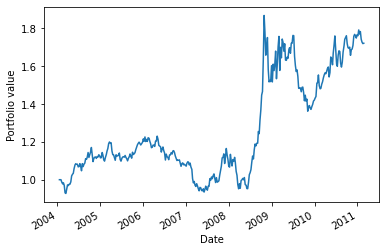

In [18]:
(1 + data.ret_google).cumprod().plot()  ## 1是本金的话 （存量+收益率）
plt.ylabel('Portfolio value')
plt.savefig("comprod.png")

**Thanks a lot for your attention!**